# Dynamic Feature Selection (GPU Accelerated)
This notebook evaluates the Optuna-tuned LightGBM model to find the mathematically optimal number of features using Gain Importance.

# Import the Libraries

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import roc_auc_score, classification_report
import warnings

warnings.filterwarnings('ignore')

WORKDIR = '/kaggle/working'
ARTIFACTS_DIR = '/kaggle/input/datasets/tahaarif23/sctp-artifacts'

# Loading Data and Tuned Parameters

In [2]:
print("1. Loading Data and Tuned Model...")
try:
    X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train.csv'))
    X_val = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_val.csv'))
    y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train.csv')).squeeze()
    y_val = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_val.csv')).squeeze()
    scaler = joblib.load(os.path.join(ARTIFACTS_DIR, 'scaler.joblib'))
    
    # Load the model to extract optimal parameters and baseline gain
    tuned_model = joblib.load(os.path.join(ARTIFACTS_DIR, 'lightgbm_model.pkl'))
    best_params = tuned_model.get_params()
    
    print("Artifacts successfully loaded!")
except Exception as e:
    print(f"Error loading artifacts: {e}")

# Scale the data
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
feature_names = X_train.columns.tolist()

1. Loading Data and Tuned Model...
Artifacts successfully loaded!


# Loading Data and Tuned Parameters

In [3]:
print("1. Loading Data and Tuned Model...")
try:
    X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train.csv'))
    X_val = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_val.csv'))
    y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train.csv')).squeeze()
    y_val = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_val.csv')).squeeze()
    scaler = joblib.load(os.path.join(ARTIFACTS_DIR, 'scaler.joblib'))
    
    # Load the model to extract optimal parameters and baseline gain
    tuned_model = joblib.load(os.path.join(ARTIFACTS_DIR, 'lightgbm_model.pkl'))
    best_params = tuned_model.get_params()
    
    print("Artifacts successfully loaded!")
except Exception as e:
    print(f"Error loading artifacts: {e}")

# Scale the data
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
feature_names = X_train.columns.tolist()

1. Loading Data and Tuned Model...
Artifacts successfully loaded!


# Extracting Gain Importance

In [4]:
print("2. Calculating Feature Importances (Gain)...")
booster = tuned_model.booster_
importances = booster.feature_importance(importance_type='gain')

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Gain': importances
}).sort_values(by='Gain', ascending=False).reset_index(drop=True)

display(importance_df.head(10))

2. Calculating Feature Importances (Gain)...


,Feature,Gain
0,var_81,132354.549545
1,var_139,116890.056725
2,var_12,91870.754707
3,var_53,83735.657276
4,var_110,82104.887695
5,var_6,75720.137161
6,var_26,74299.266018
7,var_146,72269.416607
8,var_174,71264.974735
9,var_22,67690.599270


# Step-wise Feature Evaluation

In [5]:
print("3. Exhaustive Step-wise Feature Evaluation (1 to 200)...")

# Force GPU activation for the retraining loop
best_params['device'] = 'gpu'

# Test every single feature count from 1 to 200
feature_counts_to_test = range(1, 201)
results = []

best_auc = 0
best_k = 200
best_model = None
best_features = []

for k in feature_counts_to_test:
    # Print a status update every 10 features to prevent console spam
    if k % 10 == 0 or k == 1 or k == 200:
        print(f" -> Currently evaluating Top {k} features...")
        
    top_features = importance_df['Feature'].head(k).tolist()
    top_indices = [feature_names.index(feat) for feat in top_features]
    
    X_train_sub = X_train_scaled[:, top_indices]
    X_val_sub = X_val_scaled[:, top_indices]
    
    # Initialize a fresh model with the Optuna-tuned parameters + GPU
    model_sub = LGBMClassifier(**best_params)
    
    model_sub.fit(
        X_train_sub, y_train,
        eval_set=[(X_val_sub, y_val)],
        eval_metric='auc',
        callbacks=[early_stopping(stopping_rounds=30, verbose=False), log_evaluation(0)]
    )
    
    val_proba = model_sub.predict_proba(X_val_sub)[:, 1]
    auc = roc_auc_score(y_val, val_proba)
    results.append({'k': k, 'auc': auc})
    
    # Track the absolute best model and print when we hit a new high score
    if auc > best_auc:
        print(f"    *** [NEW BEST] Top {k} features | ROC-AUC: {auc:.5f} ***")
        best_auc = auc
        best_k = k
        best_model = model_sub
        best_features = top_features

print(f"\nSelection Complete! Optimal number of features: {best_k} (ROC-AUC: {best_auc:.5f})")

3. Exhaustive Step-wise Feature Evaluation (1 to 200)...
 -> Currently evaluating Top 1 features...
[LightGBM] [Info] Number of positive: 16078, number of negative: 143922
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 1
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 1 dense feature groups (0.61 MB) transferred to GPU in 0.000956 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
    *** [NEW BEST] Top 1 features | ROC-AUC: 0.57052 ***
[LightGBM] [Info] Number of positive: 16078, number of negative: 143922
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 2
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 2 dense feature groups (0.61 MB) transferred to GPU in 0.001033 secs. 0 sparse feature groups
[LightGBM] [Info] [bi

# Visualizing Results

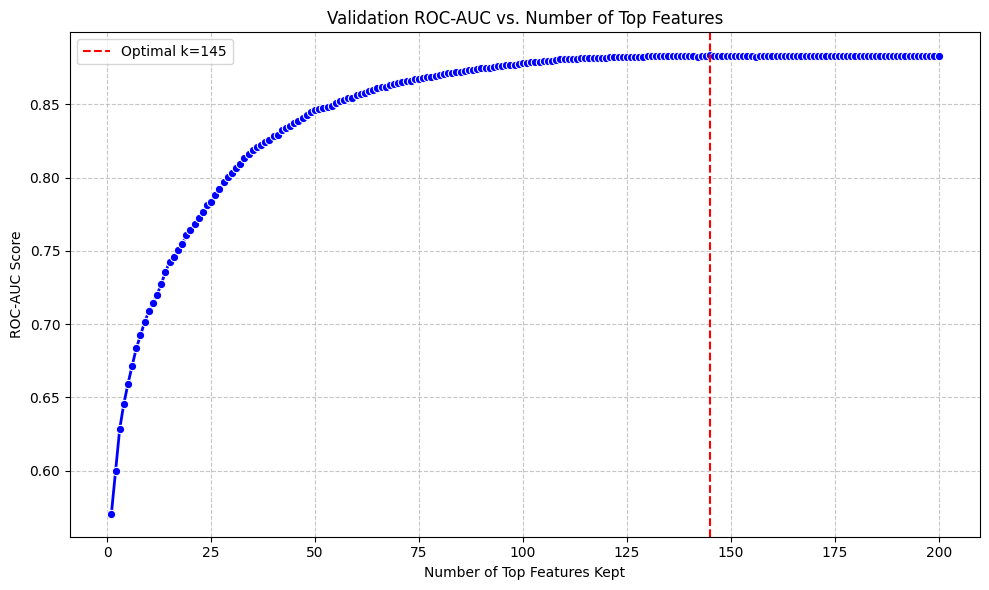

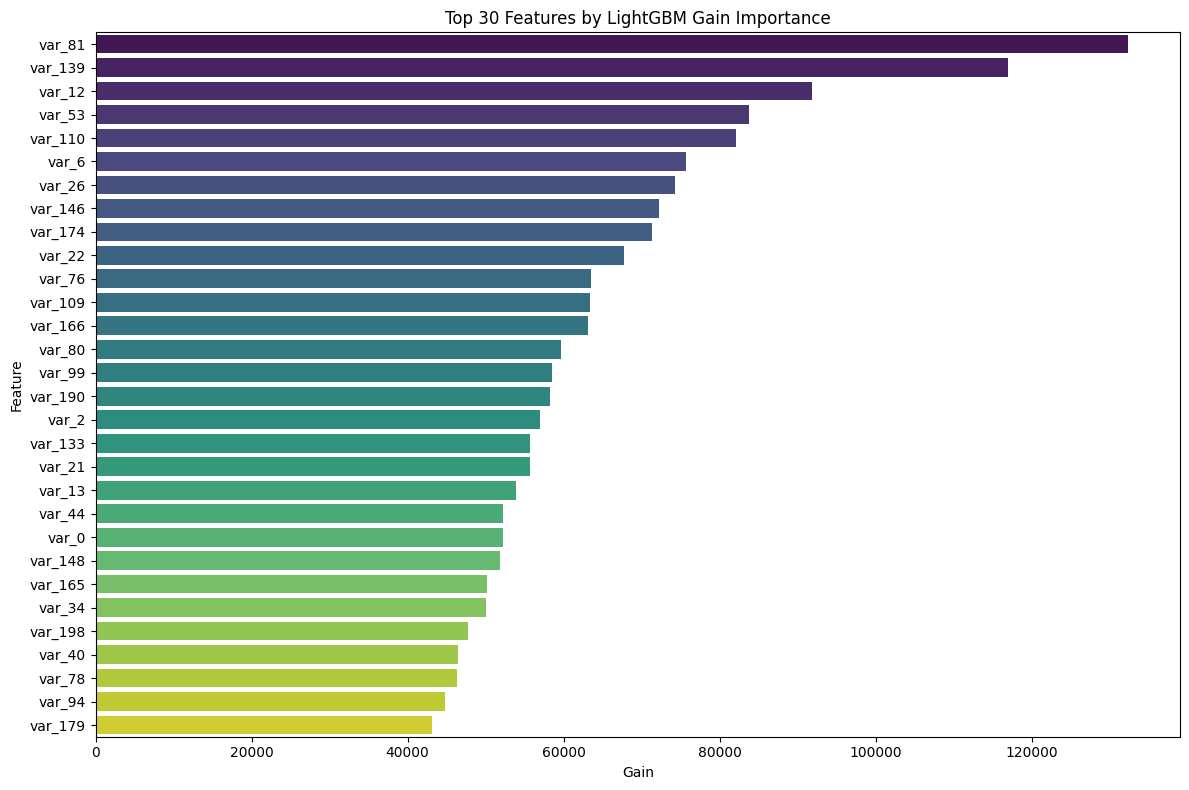

In [6]:
# --- PLOT 1: Performance vs. Number of Features ---
results_df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
sns.lineplot(x='k', y='auc', data=results_df, marker='o', linewidth=2, color='b')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Optimal k={best_k}')
plt.title('Validation ROC-AUC vs. Number of Top Features')
plt.xlabel('Number of Top Features Kept')
plt.ylabel('ROC-AUC Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(WORKDIR, 'feature_selection_curve.png'))
plt.show()

# --- PLOT 2: Top Feature Importances ---
plt.figure(figsize=(12, 8))
sns.barplot(x='Gain', y='Feature', data=importance_df.head(30), palette='viridis')
plt.title('Top 30 Features by LightGBM Gain Importance')
plt.tight_layout()
plt.savefig(os.path.join(WORKDIR, 'feature_importance_gain.png'))
plt.show()

# Saving the Final Lean Model

In [7]:
print("4. Overwriting Artifacts with the Leaner Champion Model...")

# Save the new champion model
joblib.dump(best_model, os.path.join(WORKDIR, 'lightgbm_model_lean.pkl'))

# Save the exact list of features required for this model
joblib.dump(best_features, os.path.join(WORKDIR, 'selected_features.pkl'))

print(f" -> Saved top {best_k} feature names to selected_features.pkl")
print(f" -> Saved leaner model to lightgbm_model_lean.pkl")

# Final Evaluation Printout
print("\n--- Lean Model Final Validation Report ---")
X_val_final = X_val_scaled[:, [feature_names.index(feat) for feat in best_features]]
val_pred_final = best_model.predict(X_val_final)
print(classification_report(y_val, val_pred_final))

4. Overwriting Artifacts with the Leaner Champion Model...
 -> Saved top 145 feature names to selected_features.pkl
 -> Saved leaner model to lightgbm_model_lean.pkl

--- Lean Model Final Validation Report ---
              precision    recall  f1-score   support

           0       0.97      0.83      0.90     35980
           1       0.34      0.77      0.47      4020

    accuracy                           0.82     40000
   macro avg       0.65      0.80      0.68     40000
weighted avg       0.91      0.82      0.85     40000

